# End-to-End FINN Flow for a Simple Convolutional Net
-----------------------------------------------------------------

In this notebook, we will go through the FINN steps needed to take a binarized convolutional network all the way down to a heterogeneous streaming dataflow accelerator running on the FPGA. 

It's recommended to go through the simpler [end-to-end notebook for a fully connected network](tfc_end2end_example.ipynb) first, since many steps here are very similar and we will focus on what is done differently for convolutions.

This notebook is quite lengthy, and some of the cells (involving Vivado synthesis) may take up to an hour to finish running. To let you save and resume your progress, we will save the intermediate ONNX models that are generated in the various steps to disk, so that you can jump back directly to where you left off.

## Quick Introduction to the CNV-w1a1 Network

The particular quantized neural network (QNN) we will be targeting in this notebook is referred to as CNV-w1a1 and it classifies 32x32 RGB images into one of ten CIFAR-10 classes. All weights and activations in this network are quantized to bipolar values (either -1 or +1), with the exception of the input (which is RGB with 8 bits per channel) and the final output (which is 32-bit numbers). It first appeared in the original [FINN paper](https://arxiv.org/abs/1612.07119) from ISFPGA'17 with the name CNV, as a variant of the binarized convolutional network from the [BinaryNet paper](https://arxiv.org/abs/1602.02830), in turn inspired by the VGG-11 topology which was the runner-up for the 2014 [ImageNet Large Scale Visual Recognition Challenge](http://www.image-net.org/challenges/LSVRC/).


You'll have a chance to interactively examine the layers that make up the network in Netron in a moment, so that's enough about the network for now. 

## Quick Recap of the End-to-End Flow

The FINN compiler comes with many *transformations* that modify the ONNX representation of the network according to certain patterns. This notebook will demonstrate a *possible* sequence of such transformations to take a particular trained network all the way down to hardware, as shown in the figure below.

![](finn-design-flow-example.svg)

The white fields show the state of the network representation in the respective step. The colored fields represent the transformations that are applied to the network to achieve a certain result. The diagram is divided into 5 sections represented by a different color, each of it includes several flow steps. The flow starts in top left corner with Brevitas export (green section), followed by the preparation of the network (blue section) to bring the network into a form in which each layer can be represented by either a Vitis HLS function or a Verilog module. The model then gets passed to Vivado IPI stitching (orange section), and finally a PYNQ overlay bitfile is built and can be tested on a PYNQ board (yellow section).
There is an additional section for functional verification (red section) on the right side of the diagram, which we will not cover in this notebook. For details please take a look in the verification notebook which you can find [here](tfc_end2end_verification.ipynb)


We will use the helper function `showInNetron` to show the ONNX model at the current transformation step. The Netron displays are interactive, but they only work when running the notebook actively and not on GitHub (i.e. if you are viewing this on GitHub you'll only see blank squares).

In [1]:
from finn.util.basic import make_build_dir
from finn.util.visualization import showInNetron
import os
    
build_dir = os.environ["FINN_BUILD_DIR"]
print(f"🎯 最終設定值: {build_dir}")

🎯 最終設定值: /home/barkie1/finn_build


## 1. Brevitas Export, FINN Import and Tidy-Up

Similar to what we did in the TFC-w1a1 end-to-end notebook, we will start by exporting the [pretrained CNV-w1a1 network](https://github.com/Xilinx/brevitas/tree/master/src/brevitas_examples/bnn_pynq) to ONNX, importing that into FINN and running the "tidy-up" transformations to have a first look at the topology. The network will be exported in QONNX format and then converted into the FINN-ONNX format to prepare it for the FINN compiler.

In [2]:
import torch
import os
import sys

# ==========================================
# 0. 環境設定與引用修正 (最重要的一步)
# ==========================================
# 強制將當前目錄加入 Python 路徑，確保能讀到旁邊的 CNV.py
sys.path.append(os.getcwd())

from brevitas.export import export_qonnx
from qonnx.util.cleanup import cleanup as qonnx_cleanup
from qonnx.core.modelwrapper import ModelWrapper
from finn.transformation.qonnx.convert_qonnx_to_finn import ConvertQONNXtoFINN
from qonnx.transformation.infer_shapes import InferShapes
from qonnx.transformation.fold_constants import FoldConstants
from qonnx.transformation.general import GiveReadableTensorNames, GiveUniqueNodeNames, RemoveStaticGraphInputs

# 【關鍵修改】直接從本地檔案引用 CNV，而不是從安裝包引用
try:
    from CNV import CNV
    print(f"✅ 成功載入本地端的修改版 CNV (包含 Adapter 支援)")
except ImportError as e:
    print("❌ 載入失敗！請確認：")
    print("1. CNV.py 是否在 adapter.ipynb 旁邊？")
    print("2. 是否已依照指示修改 CNV.py 內的 import 路徑 (移除 .common)？")
    raise e

# ==========================================
# 1. 設定路徑
# ==========================================
# 請確保這個 "adapter.tar" 是那個包含完整 Adapter/RC 參數的 best.tar (複製過來的)
checkpoint_path = "adapter.tar"  

# 確保輸出目錄存在
if not os.path.exists(build_dir):
    os.makedirs(build_dir)

export_onnx_path = build_dir + "/adapter.onnx"
final_output_path = build_dir + "/adapter.onnx"

# ==========================================
# 2. 建立模型 (加入 Adapter 設定)
# ==========================================
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"找不到 {checkpoint_path}，請確認檔案已上傳至根目錄！")

print(f"正在讀取權重: {checkpoint_path}")

# 設定 Adapter 參數 (必須跟訓練時一樣)
adapter_config = {
    'num_branches': 1,   # 請確認這是您訓練時用的分支數 (m)
    'bit_width': 1,      # Adapter 位元數
    'rc_bit_width': 8,   # RC 位元數
    'use_rc': True       # 是否使用 RC
}

# 建立模型實體
print("正在建立包含 Adapter 的完整模型結構...")
try:
    model_torch = CNV(
        num_classes=10, 
        weight_bit_width=1, 
        act_bit_width=1, 
        in_bit_width=8, 
        in_ch=3, 
        adapter_config=adapter_config  # <--- 傳入設定
    )
except TypeError as e:
    print("❌ 錯誤：CNV 不接受 adapter_config 參數。")
    print("原因：Python 讀到了舊版的 CNV.py。")
    print("解法：請重啟 Jupyter Kernel (Kernel -> Restart) 讓它重新載入修改後的檔案。")
    raise e

# ==========================================
# 3. 載入權重 (全網路載入)
# ==========================================
checkpoint = torch.load(checkpoint_path, map_location='cpu')

if 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

# 直接載入所有參數
try:
    model_torch.load_state_dict(state_dict, strict=True)
    print("✅ 成功載入完整參數 (Backbone + Adapter + RC)！")
except RuntimeError as e:
    print("❌ 載入失敗！請確認您的 adapter.tar 是 `best.tar` (全配版)。")
    print(f"詳細錯誤: {e}")
    raise e

model_torch.eval()

# ==========================================
# 4. 匯出與 FINN 轉換
# ==========================================
print(f"正在匯出 ONNX: {export_onnx_path}")
dummy_input = torch.randn(1, 3, 32, 32)
export_qonnx(model_torch, input_t=dummy_input, export_path=export_onnx_path)

print("正在執行 FINN 清理與轉換...")
qonnx_cleanup(export_onnx_path, out_file=export_onnx_path)

model = ModelWrapper(export_onnx_path)
model = model.transform(ConvertQONNXtoFINN())
model = model.transform(InferShapes())
model = model.transform(FoldConstants())
model = model.transform(GiveUniqueNodeNames())
model = model.transform(GiveReadableTensorNames())
model = model.transform(RemoveStaticGraphInputs())

# 存檔
model.save(build_dir + "/adapter_tidy.onnx")
print("-" * 50)
print(f"🎉 轉換成功！")
print("-" * 50)

✅ 成功載入本地端的修改版 CNV (包含 Adapter 支援)
正在讀取權重: adapter.tar
正在建立包含 Adapter 的完整模型結構...
✅ 成功載入完整參數 (Backbone + Adapter + RC)！
正在匯出 ONNX: /home/barkie1/finn_build/adapter.onnx
正在執行 FINN 清理與轉換...
--------------------------------------------------
🎉 轉換成功！
--------------------------------------------------


Now that the model is exported, let's have a look at its layer structure with Netron. Remember that the visualization below is interactive, you can click on the individual nodes and view the layer attributes, trained weights and so on.

In [4]:
showInNetron(build_dir+"/adapter_tidy.onnx")

OSError: [Errno 98] Address already in use

You can see that the network is composed of a repeating convolution-convolution-maxpool layer pattern to extract features using 3x3 convolution kernels (with weights binarized), followed by fully connected layers acting as the classifier. Also notice the initial `MultiThreshold` layer at the beginning of the network, which is quantizing float inputs to 8-bit ones.

### Adding Pre- and Postprocessing <a id='prepost'></a>
把「除以 255」這個前處理動作（Preprocessing），直接燒進 ONNX 模型的最前面



Preprocessing and postprocessing steps can be added directly in the ONNX graph. In this case, the preprocessing step divides the input `uint8` data by 255 so the inputs to the CNV-w1a1 network are bounded between [0, 1]. The postprocessing step takes the output of the network and returns the index (0-9) of the image category with the highest probability (top-1). 

In [3]:
from finn.util.pytorch import ToTensor
from qonnx.transformation.merge_onnx_models import MergeONNXModels
from qonnx.core.datatype import DataType

model = ModelWrapper(build_dir+"/adapter_tidy.onnx")
global_inp_name = model.graph.input[0].name
ishape = model.get_tensor_shape(global_inp_name)
# preprocessing: torchvision's ToTensor divides uint8 inputs by 255
totensor_pyt = ToTensor()
chkpt_preproc_name = build_dir+"/adapter_preproc.onnx"
export_qonnx(totensor_pyt, torch.randn(ishape), chkpt_preproc_name)
qonnx_cleanup(chkpt_preproc_name, out_file=chkpt_preproc_name)
pre_model = ModelWrapper(chkpt_preproc_name)
pre_model = pre_model.transform(ConvertQONNXtoFINN())

# join preprocessing and core model
model = model.transform(MergeONNXModels(pre_model))
# add input quantization annotation: UINT8 for all BNN-PYNQ models
global_inp_name = model.graph.input[0].name
model.set_tensor_datatype(global_inp_name, DataType["UINT8"])

/home/barkie1/thesis/finn/deps/qonnx/src/qonnx/transformation/infer_data_layouts.py:127: UserWarning: Assuming 4D input is NCHW
  warnings.warn("Assuming 4D input is NCHW")


In [26]:
### 用來在模型最後面加一個 Top-K 節點，也就是直接讓硬體吐出「分類結果的編號（Index）」，而不是吐出所有類別的機率值。

In [4]:
from qonnx.transformation.insert_topk import InsertTopK
from qonnx.transformation.infer_datatypes import InferDataTypes

# postprocessing: insert Top-1 node at the end
model = model.transform(InsertTopK(k=1))
chkpt_name = build_dir+"/adapter_pre_post.onnx"
# tidy-up again
model = model.transform(InferShapes())
model = model.transform(FoldConstants())
model = model.transform(GiveUniqueNodeNames())
model = model.transform(GiveReadableTensorNames())
model = model.transform(InferDataTypes())
model = model.transform(RemoveStaticGraphInputs())
model.save(chkpt_name)

In [7]:
showInNetron(build_dir+"/adapter_pre_post.onnx")

OSError: [Errno 98] Address already in use

## 2. How FINN Implements Convolutions: Lowering and Streamlining

In FINN, we implement convolutions with the *lowering* approach: we convert them to matrix-matrix multiply operations, where one of the matrices is generated by sliding a window over the input image. You can read more about the sliding window operator and how convolution lowering works [in this notebook](https://github.com/maltanar/qnn-inference-examples/blob/master/3-convolutional-binarized-gtsrb.ipynb). The streaming dataflow architecture we will end up with is going to look something like this figure from the [FINN-R paper](https://arxiv.org/abs/1809.04570):

![](cnv-mp-fc.png)

Note how the convolution layer looks very similar to the fully connected one in terms of the matrix-vector-threshold unit (MVTU) or sometimes called matrix-vector-activation unit (MVAU). But now the MVTU is preceded by a sliding window unit that produces the matrix from the input image. All of these building blocks, including the `MaxPool` layer you see in this figure, exist as templated Vitis HLS C++ functions in [finn-hlslib](https://github.com/Xilinx/finn-hlslib) and/or as RTL modules in [finn-rtllib](https://github.com/Xilinx/finn/tree/main/finn-rtllib).


To target this kind of hardware architecture with our network we'll apply a convolution lowering transformation, in addition to streamlining. You may recall the *streamlining transformation* that we applied to the TFC-w1a1 network, which is a series of mathematical simplifications that allow us to get rid of floating point scaling operations by implementing few-bit activations as thresholding operations. 

**The current implementation of streamlining is highly network-specific and may not work for your network if its topology is very different than the example network here. We hope to rectify this in future releases.**

In [ ]:
from qonnx.core.modelwrapper import ModelWrapper

from finn.transformation.streamline import Streamline
import finn.transformation.streamline.absorb as absorb
from finn.transformation.streamline.reorder import (
    MakeMaxPoolNHWC,
    MoveScalarLinearPastInvariants,
)

from qonnx.transformation.lower_convs_to_matmul import LowerConvsToMatMul
from qonnx.transformation.bipolar_to_xnor import ConvertBipolarMatMulToXnorPopcount
from qonnx.transformation.infer_shapes import InferShapes
from qonnx.transformation.infer_datatypes import InferDataTypes
from qonnx.transformation.infer_data_layouts import InferDataLayouts
from qonnx.transformation.general import RemoveUnusedTensors


def dump_step(model, build_dir, tag):
    """每一步存一份，方便你用 Netron 對照是哪一步開始壞掉。"""
    out = f"{build_dir}/debug_{tag}.onnx"
    model.save(out)
    print(f"[dump] saved {out}")


def reinfer_all(model):
    """把 shape/layout/datatype 重新推乾淨。"""
    model = model.transform(InferDataLayouts())
    model = model.transform(InferDataTypes())
    model = model.transform(InferShapes())
    return model


def clear_value_info(model):
    """清掉舊 value_info，避免 inferred vs existing 衝突，但清完要立刻 reinfer。"""
    del model.graph.value_info[:]
    return model


# =========================
# main
# =========================
model = ModelWrapper(build_dir + "/adapter_pre_post.onnx")

# (A) 先推一次 shape/layout/type，確保後面 MakeMaxPoolNHWC 不會拿到 ishape=None
model = reinfer_all(model)
dump_step(model, build_dir, "00_reinfer_init")

# (B) 前置標準優化
model = model.transform(MoveScalarLinearPastInvariants())
model = reinfer_all(model)
dump_step(model, build_dir, "01_move_scalar")

model = model.transform(Streamline())
model = reinfer_all(model)
dump_step(model, build_dir, "02_streamline")

model = model.transform(LowerConvsToMatMul())
model = reinfer_all(model)
dump_step(model, build_dir, "03_lower_convs")

# (C) 轉 NHWC：這步最容易因為分支 + transpose 造成 shape 註記衝突
# 先清一次舊 value_info，避免「舊的 NCHW 註記」跟「新插入 transpose 的推論」互打
model = clear_value_info(model)
model = reinfer_all(model)
dump_step(model, build_dir, "04_clear_then_reinfer")

model = model.transform(MakeMaxPoolNHWC())
model.save(build_dir + "/debug_05_after_make_maxpoolnhwc.onnx")
try:
    model = reinfer_all(model)
except Exception as _e:
    print(f"[reinfer_all after MakeMaxPoolNHWC failed, continuing: {_e}]")
    model = clear_value_info(model)

model = model.transform(absorb.AbsorbTransposeIntoMultiThreshold())
model = reinfer_all(model)
dump_step(model, build_dir, "06_absorb_transpose_into_mt")

# (D) XNOR / popcount 轉換
model = model.transform(ConvertBipolarMatMulToXnorPopcount())
model = reinfer_all(model)
dump_step(model, build_dir, "07_bipolar_to_xnor")

# (E) 收尾
model = model.transform(Streamline())
model = reinfer_all(model)
dump_step(model, build_dir, "08_streamline2")

model = model.transform(absorb.AbsorbScalarMulAddIntoTopK())
model = reinfer_all(model)
dump_step(model, build_dir, "09_absorb_muladd_topk")

model = model.transform(RemoveUnusedTensors())
model = reinfer_all(model)
dump_step(model, build_dir, "10_remove_unused")

model.save(build_dir + "/adapter_streamlined.onnx")
print("[ok] saved adapter_streamlined.onnx")


We won't go into too much detail about what happens in each transformation and why they are called in the particular order they are (feel free to visualize the intermediate steps using Netron yourself if you are curious) but here is a brief summary:

* `Streamline` moves floating point scaling and addition operations closer to the input of the nearest thresholding activation and absorbs them into thresholds
* `LowerConvsToMatMul` converts ONNX `Conv` nodes into sequences of `Im2Col, MatMul` nodes as discussed above. `Im2Col` is a custom FINN ONNX high-level node type that implements the sliding window operator.
* `MakeMaxPoolNHWC` and `AbsorbTransposeIntoMultiThreshold` convert the *data layout* of the network into the NHWC data layout that finn-hlslib and finn-rtllib primitives use. NCHW means the tensor dimensions are ordered as `(N : batch, H : height, W : width, C : channels)` (assuming 2D images). The ONNX standard ops normally use the NCHW layout, but the ONNX intermediate representation itself does not dictate any data layout.
* You may recall `ConvertBipolarMatMulToXnorPopcount` from the TFC-w1a1 example, which is needed to implement bipolar-by-bipolar (w1a1) networks correctly using finn-hlslib.

Let's visualize the streamlined and lowered network with Netron. Observe how all the `Conv` nodes have turned into pairs of `Im2Col, MatMul` nodes, and many nodes including `BatchNorm, Mul, Add` nodes have disappeared and replaced with `MultiThreshold` nodes.

In [10]:
showInNetron(build_dir+"/Cifar10_backbone_streamlined.onnx")

Serving '/home/barkie1/finn_build/Cifar10_backbone_streamlined.onnx' at http://0.0.0.0:8081


## 3. Partitioning, Conversion to HW Layers and Folding

The next steps will be (again) very similar to what we did for the TFC-w1a1 network. We'll first convert the layers that we can put into the FPGA into their HW equivalents, separate them out into a *dataflow partition* and specialize them to HLS variants:


In [25]:
from finn.util.basic import pynq_part_map
from qonnx.core.modelwrapper import ModelWrapper
from qonnx.core.datatype import DataType
import finn.transformation.fpgadataflow.convert_to_hw_layers as to_hw
from finn.transformation.fpgadataflow.create_dataflow_partition import CreateDataflowPartition
from finn.transformation.move_reshape import RemoveCNVtoFCFlatten
from finn.transformation.fpgadataflow.specialize_layers import SpecializeLayers
from qonnx.custom_op.registry import getCustomOp
from qonnx.transformation.infer_data_layouts import InferDataLayouts
from qonnx.transformation.general import GiveUniqueNodeNames, RemoveUnusedTensors
from qonnx.transformation.infer_shapes import InferShapes
from qonnx.transformation.infer_datatypes import InferDataTypes
import finn.transformation.streamline.absorb as absorb
from qonnx.util.basic import get_by_name

# 設定開發板資訊
pynq_board = "Pynq-Z2"
fpga_part = pynq_part_map[pynq_board]
target_clk_ns = 10

# 載入模型
print("📥 載入 Streamline 後的模型...")
model = ModelWrapper(build_dir + "/adapter_streamlined.onnx")

# =========================================================
# 🛑 破解死鎖：精準保留 + 核彈清理
# =========================================================
print("🚑 執行死鎖破解程序...")

graph = model.graph
maxpool_inputs = {}

# 1. 【備份】 計算所有 MaxPoolNHWC 需要的輸入形狀
for node in graph.node:
    if node.op_type == "Transpose":
        consumer = model.find_consumer(node.output[0])
        if consumer is not None and consumer.op_type == "MaxPoolNHWC":
            # 這是關鍵節點！我們必須計算出正確的 Shape 並備份下來
            input_shape = model.get_tensor_shape(node.input[0])
            if input_shape is not None:
                perm_attr = get_by_name(node.attribute, "perm")
                perm = list(perm_attr.ints) if perm_attr else [0, 2, 3, 1]
                new_shape = [input_shape[p] for p in perm]
                
                # 存入備份字典 {tensor_name: shape}
                maxpool_inputs[node.output[0]] = new_shape
                print(f"🔒 鎖定關鍵形狀: {node.output[0]} -> {new_shape}")

# 2. 【核彈】 清除全圖所有 Shape 資訊 (解決 32 vs 16 的根本方法)
print("☢️  執行核彈級清理 (清除所有舊標籤)...")
del graph.value_info[:]

# 3. 【還原】 只寫回關鍵的 MaxPoolNHWC 輸入 (解決 NoneType)
print("🛡️  還原關鍵形狀...")
for name, shape in maxpool_inputs.items():
    model.set_tensor_shape(name, shape)

# 4. 【重建】 讓 FINN 在乾淨的環境下重新推論全圖
print("🔄 重建全圖形狀...")
model = model.transform(InferDataTypes())
model = model.transform(InferShapes())
print("✅ 形狀重建完成！沒有報錯就是成功了。")

# =========================================================
# 1. 硬體層轉換 (HW Conversion)
# =========================================================
print("🛠️ 開始將模型轉換為硬體層...")

model = model.transform(to_hw.InferBinaryMatrixVectorActivation())
model = model.transform(to_hw.InferQuantizedMatrixVectorActivation())
model = model.transform(to_hw.InferConvInpGen())
model = model.transform(to_hw.InferStreamingMaxPool())
model = model.transform(to_hw.InferLabelSelectLayer())
model = model.transform(to_hw.InferThresholdingLayer())

fc_layers = model.get_nodes_by_op_type("MVAU_hls")
print(f"🧐 檢查轉換結果：找到了 {len(fc_layers)} 個 MVAU_hls 硬體層")

# =========================================================
# 2. 結構整理
# =========================================================
print("🧹 整理硬體結構...")
model = model.transform(RemoveCNVtoFCFlatten())
model = model.transform(absorb.AbsorbConsecutiveTransposes())
model = model.transform(InferDataLayouts())
model = model.transform(GiveUniqueNodeNames())
model.save(build_dir + "/adapter_hw_layers.onnx")

# =========================================================
# 3. 建立資料流分區
# =========================================================
print("📦 建立 Dataflow Partition...")
try:
    parent_model = model.transform(CreateDataflowPartition())
    parent_model.save(build_dir + "/adapter_dataflow_parent.onnx")
    
    sdp_nodes = parent_model.get_nodes_by_op_type("StreamingDataflowPartition")
    if len(sdp_nodes) > 0:
        sdp_node = sdp_nodes[0]
        print("✅ 成功建立 StreamingDataflowPartition！")
    else:
        raise IndexError("Partition list is empty")     
except Exception as e:
    print(f"❌ Partitioning 失敗: {str(e)}")
    raise e

# =========================================================
# 4. 硬體特化
# =========================================================
print(f"⚡ 針對 {pynq_board} 進行硬體特化...")
sdp_node = getCustomOp(sdp_node)
dataflow_model_filename = sdp_node.get_nodeattr("model")
dataflow_model = ModelWrapper(dataflow_model_filename)
dataflow_model = dataflow_model.transform(SpecializeLayers(fpga_part))
dataflow_model.save(build_dir + "/adapter_dataflow_model.onnx")

print("🎉 硬體轉換完成！檔案已儲存至:", build_dir + "/adapter_dataflow_model.onnx")

📥 載入 Streamline 後的模型...
🚑 執行死鎖破解程序...
🔒 鎖定關鍵形狀: MaxPool_0_out0 -> [1, 32, 32, 64]
🔒 鎖定關鍵形狀: MaxPool_1_out0 -> [1, 16, 16, 128]
☢️  執行核彈級清理 (清除所有舊標籤)...
🛡️  還原關鍵形狀...
🔄 重建全圖形狀...
✅ 形狀重建完成！沒有報錯就是成功了。
🛠️ 開始將模型轉換為硬體層...


TypeError: 'NoneType' object is not subscriptable

Notice the additional `RemoveCNVtoFCFlatten` transformation that was not used for TFC-w1a1. In the last Netron visualization you may have noticed a `Reshape` operation towards the end of the network where the convolutional part of the network ends and the fully-connected layers started. That `Reshape` is essentialy a tensor flattening operation, which we can remove for the purposes of hardware implementation. We can examine the contents of the dataflow partition with Netron, and observe the `ConvolutionInputGenerator`, `MatrixVectorActivation` and `StreamingMaxPool_Batch` nodes that implement the sliding window, matrix multiply and maxpool operations. *Note that the MatrixVectorActivation instances following the ConvolutionInputGenerator nodes are really implementing the convolutions, despite the name. The final three MatrixVectorActivation instances implement actual FC layers.*

In [13]:
showInNetron(build_dir + "/Cifar10_backbone_dataflow_parent.onnx")

Serving '/home/barkie1/finn_build/Cifar10_backbone_dataflow_parent.onnx' at http://0.0.0.0:8081


Note that pretty much everything has gone into the `StreamingDataflowPartition` node; the only operation remaining is to apply a `Transpose` to obtain NHWC input from a NCHW input (the ONNX default). 

In [15]:
showInNetron(build_dir + "/Cifar10_backbone_dataflow_model.onnx")

Serving '/home/barkie1/finn_build/Cifar10_backbone_dataflow_model.onnx' at http://0.0.0.0:8081


Now we have to set the *folding factors* for certain layers to adjust the performance of our accelerator, similar to the TFC-w1a1 example. We'll also set the desired FIFO depths around those layers, which are important to achieve full throughput in the accelerator.

In [ ]:
model = ModelWrapper(build_dir + "/Cifar10_backbone_dataflow_model.onnx")
fc_layers = model.get_nodes_by_op_type("MVAU_hls")
# each tuple is (PE, SIMD, in_fifo_depth) for a layer
folding = [
    (1, 3, [128]),
    (1, 32, [128]),
    (1, 32, [128]),
    (1, 32, [128]),
    (1, 32, [81]),
    (1, 32, [2]),
    (1, 4, [2]),
    (1, 8, [128]),
    (1, 1, [3]),
]
for fcl, (pe, simd, ififodepth) in zip(fc_layers, folding):
    fcl_inst = getCustomOp(fcl)
    fcl_inst.set_nodeattr("PE", pe)
    fcl_inst.set_nodeattr("SIMD", simd)
    fcl_inst.set_nodeattr("inFIFODepths", ififodepth)

# use same SIMD values for the sliding window operators
swg_layers = model.get_nodes_by_op_type("ConvolutionInputGenerator_rtl")
for i in range(len(swg_layers)):
    swg_inst = getCustomOp(swg_layers[i])
    simd = folding[i][1]
    swg_inst.set_nodeattr("SIMD", simd)

model = model.transform(GiveUniqueNodeNames())
model.save(build_dir + "/Cifar10_backbone_folded.onnx")

Below we visualize in Netron to observe the folding factors in the `PE` and `SIMD` attributes of each `MVAU_hls`.

In [18]:
showInNetron(build_dir + "/Cifar10_backbone_folded.onnx")

Serving '/home/barkie1/finn_build/Cifar10_backbone_folded.onnx' at http://0.0.0.0:8081


Our network is now ready and we can start with the hardware generation.

## 4. Hardware Generation

From this point onward, the steps we have to follow do not depend on the particular network and will be exactly the same as the TFC-w1a1 example. **which may take about 30 minutes depending on your host computer**. For more details about what's going on in this step, please consult the [TFC end-to-end notebook](tfc_end2end_example.ipynb) or the appropriate section in the [FINN documentation](https://finn.readthedocs.io/en/latest/hw_build.html).

In [12]:
from finn.transformation.fpgadataflow.make_zynq_proj import ZynqBuild
model = ModelWrapper(build_dir+"/cnv_6layer_fc3_cifar_w1a1_folded.onnx")
model = model.transform(ZynqBuild(platform = pynq_board, period_ns = target_clk_ns))

/home/barkie1/thesis/finn/src/finn/transformation/fpgadataflow/floorplan.py:107: UserWarning: 32 nodes have no entry in the provided floorplan, SLR was set to -1
  warnings.warn(
/home/barkie1/thesis/finn/src/finn/transformation/fpgadataflow/insert_fifo.py:234: UserWarning: Input FIFO for IODMA_hls_0_out0 has depth 2 and won't
                        be created. This may cause RTL simulation issues.
                        
  warnings.warn(
/home/barkie1/thesis/finn/src/finn/transformation/fpgadataflow/insert_fifo.py:294: UserWarning: Output FIFO for LabelSelect_hls_0_out0 has depth 2 and won't
                        be created. This may cause RTL simulation issues.
                        
  warnings.warn(
/home/barkie1/thesis/finn/src/finn/transformation/fpgadataflow/create_stitched_ip.py:290: UserWarning: First node is not StreamingFIFO or IODMA.
                You may experience incorrect stitched-IP rtlsim or hardware
                behavior. It is strongly recommended to inser

After the `ZynqBuild` we run one additional transformation to generate a PYNQ driver for the accelerator.

In [13]:
from finn.transformation.fpgadataflow.make_pynq_driver import MakePYNQDriver
model = model.transform(MakePYNQDriver("zynq-iodma"))

In [14]:
model.save(build_dir + "/cnv_6layer_fc3_cifar_w1a1_synth.onnx")

## 5. Deployment and Execution

The bitfile and generated driver files(s) will be copied into a deployment folder which then can be used to run the network on the PYNQ board.

In [15]:
from shutil import copy
from distutils.dir_util import copy_tree

# create directory for deployment files
deployment_dir = make_build_dir(prefix="pynq_deployment_")
model.set_metadata_prop("pynq_deployment_dir", deployment_dir)

# get and copy necessary files
# .bit and .hwh file
bitfile = model.get_metadata_prop("bitfile")
hwh_file = model.get_metadata_prop("hw_handoff")
deploy_files = [bitfile, hwh_file]

for dfile in deploy_files:
    if dfile is not None:
        copy(dfile, deployment_dir)

# driver.py and python libraries
pynq_driver_dir = model.get_metadata_prop("pynq_driver_dir")
copy_tree(pynq_driver_dir, deployment_dir)

creating /home/barkie1/finn_build/pynq_deployment_3opfn1s4/runtime_weights
copying /home/barkie1/finn_build/pynq_driver_fohf7zlo/driver_base.py -> /home/barkie1/finn_build/pynq_deployment_3opfn1s4
creating /home/barkie1/finn_build/pynq_deployment_3opfn1s4/finn
creating /home/barkie1/finn_build/pynq_deployment_3opfn1s4/finn/util
copying /home/barkie1/finn_build/pynq_driver_fohf7zlo/finn/util/__init__.py -> /home/barkie1/finn_build/pynq_deployment_3opfn1s4/finn/util
copying /home/barkie1/finn_build/pynq_driver_fohf7zlo/finn/util/data_packing.py -> /home/barkie1/finn_build/pynq_deployment_3opfn1s4/finn/util
copying /home/barkie1/finn_build/pynq_driver_fohf7zlo/driver.py -> /home/barkie1/finn_build/pynq_deployment_3opfn1s4
copying /home/barkie1/finn_build/pynq_driver_fohf7zlo/validate.py -> /home/barkie1/finn_build/pynq_deployment_3opfn1s4
creating /home/barkie1/finn_build/pynq_deployment_3opfn1s4/qonnx
creating /home/barkie1/finn_build/pynq_deployment_3opfn1s4/qonnx/core
copying /home/bar

['/home/barkie1/finn_build/pynq_deployment_3opfn1s4/driver_base.py',
 '/home/barkie1/finn_build/pynq_deployment_3opfn1s4/finn/util/__init__.py',
 '/home/barkie1/finn_build/pynq_deployment_3opfn1s4/finn/util/data_packing.py',
 '/home/barkie1/finn_build/pynq_deployment_3opfn1s4/driver.py',
 '/home/barkie1/finn_build/pynq_deployment_3opfn1s4/validate.py',
 '/home/barkie1/finn_build/pynq_deployment_3opfn1s4/qonnx/core/__init__.py',
 '/home/barkie1/finn_build/pynq_deployment_3opfn1s4/qonnx/core/datatype.py',
 '/home/barkie1/finn_build/pynq_deployment_3opfn1s4/qonnx/util/basic.py',
 '/home/barkie1/finn_build/pynq_deployment_3opfn1s4/qonnx/util/__init__.py']

Next to these files, we will also need an example numpy array to test the network on the PYNQ board. (*and before you ask, that's supposed to be a cat (CIFAR-10 class number 3)*) Recall that we partitioned our original network into a parent graph that contained the non-synthesizable nodes and a child graph that contained the bulk of the network, which we turned into a bitfile. The only operator left outside the FPGA partition was a `Transpose` to convert NCHW images into NHWC ones. Thus, we can skip the execution in the parent as long as we ensure our image has the expected data layout. The example numpy array can then be saved as .npy file.

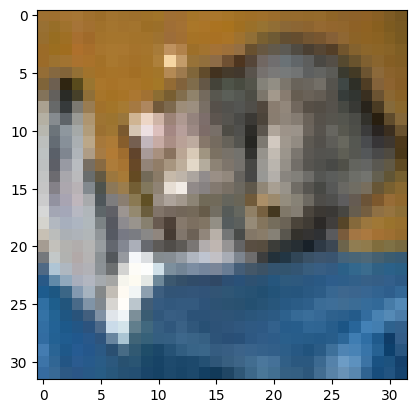

In [37]:
import importlib_resources
import matplotlib.pyplot as plt
import numpy as np

ref = importlib_resources.files("finn.qnn-data") / "cifar10/cifar10-test-data-class3.npz"
with importlib_resources.as_file(ref) as fn:
    x = np.load(fn)["arr_0"]
x = x.reshape(3, 32,32).transpose(1, 2, 0)
plt.imshow(x)

In [38]:
model = ModelWrapper(build_dir + "/cnv_6layer_fc3_svhn_w1a1_synth.onnx")
iname = model.graph.input[0].name
ishape = model.get_tensor_shape(iname)
np.save(deployment_dir + "/input.npy", x.reshape(ishape))

In [39]:
! ls {deployment_dir}

driver_base.py	finn	   qonnx	resizer.hwh	 validate.py
driver.py	input.npy  resizer.bit	runtime_weights


In [40]:
from shutil import make_archive
make_archive('cnv_6layer_fc3_cifar_w1a1', 'zip', deployment_dir)

'/home/barkie1/thesis/finn/notebooks/end2end_example/bnn-pynq/cnv_6layer_fc3_svhn_w1a1.zip'

You can now download the created zipfile (File -> Open, mark the checkbox next to the deploy-on-pynq-tfc.zip and select Download from the toolbar), then copy it to your PYNQ board (for instance via scp or rsync). Then, run the following commands on the PYNQ board to extract the archive and run the execution:

```shell
unzip deploy-on-pynq-cnv.zip -d finn-cnv-demo
cd finn-cnv-demo
sudo python3 -m pip install bitstring
sudo python3 driver.py --exec_mode=execute --batchsize=1 --bitfile=resizer.bit --inputfile=input.npy
```

The output will be saved on the PYNQ board as `output.npy` and can be copied to the host and opened with `np.load()`.

### Validating the Accuracy on a PYNQ Board <a id='validation'></a>

All the command line prompts here are meant to be executed with `sudo` on the PYNQ board.

**Ensure that your PYNQ board has a working internet connecting for the next steps, since some there is some downloading involved.**

To validate the accuracy, we first need to install the [`dataset-loading`](https://github.com/fbcotter/dataset_loading) Python package to the PYNQ board. This will give us a convenient way of downloading and accessing the MNIST dataset.


Command to execute on PYNQ:

```shell
sudo pip3 install git+https://github.com/fbcotter/dataset_loading.git@0.0.4#egg=dataset_loading
```

We can now use the `validate.py` script that was generated together with the driver to measure top-1 accuracy on the CIFAR-10 dataset.

Command to execute on PYNQ:

```shell
sudo python3 validate.py --dataset cifar10 --batchsize 1000
```

We see that the final top-1 accuracy is 84.19%, which is very close to the 84.22% reported on the [BNN-PYNQ accuracy table in Brevitas](https://github.com/Xilinx/brevitas/tree/master/src/brevitas_examples/bnn_pynq). 